# 06 - Red Flag (NLP) Threshold Tuning
Questo notebook esegue la calibrazione finale della Baseline TF-IDF per ottimizzare la Recall sul Rischio Suicidario nel Validation Set, e validare il risultato sul Test Set finale.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, fbeta_score
import os

os.makedirs('../../../docs/documentazione/latex/figures', exist_ok=True)

import warnings
warnings.filterwarnings('ignore')

## 1. Caricamento Dati

In [2]:
print("Loading original splits...")
train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/val.csv')
test_df = pd.read_csv('../data/processed/test.csv')

# Drop nulls
train_df = train_df.dropna(subset=['text', 'class'])
val_df = val_df.dropna(subset=['text', 'class'])
test_df = test_df.dropna(subset=['text', 'class'])

# Convert labels (suicide=1, non-suicide=0)
label_map = {'suicide': 1, 'non-suicide': 0}
y_train = train_df['class'].map(label_map).values
y_val = val_df['class'].map(label_map).values
y_test = test_df['class'].map(label_map).values

print(f"Train size: {len(train_df)}, Val size: {len(val_df)}, Test size: {len(test_df)}")

Loading original splits...
Train size: 180050, Val size: 22506, Test size: 22507


## 2. Addestramento Baseline (Produzione)

In [3]:
print("\nTraining Baseline TF-IDF + Logistic Regression...")
vectorizer = TfidfVectorizer(max_features=10000)
X_train = vectorizer.fit_transform(train_df['text'])
X_val = vectorizer.transform(val_df['text'])
X_test = vectorizer.transform(test_df['text'])

clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(X_train, y_train)
print("Training Complete!")


Training Baseline TF-IDF + Logistic Regression...
Training Complete!


## 3. Calibrazione Soglia (Threshold Tuning)


Performing Threshold Tuning on Validation Set...
Optimal Threshold (Max F2-Score): 0.2397
  - Expected Recall:    0.9689
  - Expected Precision: 0.8812


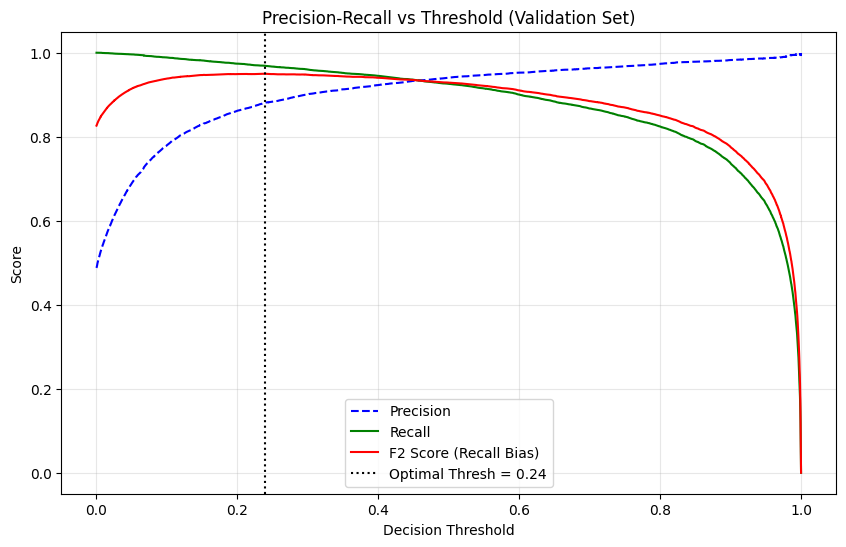

In [4]:
print("\nPerforming Threshold Tuning on Validation Set...")
y_val_prob = clf.predict_proba(X_val)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_prob)

# F2-Score per dare priorita alla Recall
beta = 2
f2_scores = (1 + beta**2) * (precisions[:-1] * recalls[:-1]) / ((beta**2 * precisions[:-1]) + recalls[:-1])

ott_idx = np.argmax(f2_scores)
optimal_threshold = thresholds[ott_idx]

print(f"Optimal Threshold (Max F2-Score): {optimal_threshold:.4f}")
print(f"  - Expected Recall:    {recalls[ott_idx]:.4f}")
print(f"  - Expected Precision: {precisions[ott_idx]:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.plot(thresholds, f2_scores, 'r-', label='F2 Score (Recall Bias)')
plt.axvline(x=optimal_threshold, color='black', linestyle=':', label=f'Optimal Thresh = {optimal_threshold:.2f}')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold (Validation Set)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../../../docs/documentazione/latex/figures/nlp_threshold_tuning.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Valutazione sul Test Set


Evaluating on TEST SET with Threshold 0.2397...

--- DEFAULT THRESHOLD (0.5) TEST EVAL ---
              precision    recall  f1-score   support

 non-suicide     0.9241    0.9447    0.9343     11532
     suicide     0.9405    0.9185    0.9293     10975

    accuracy                         0.9319     22507
   macro avg     0.9323    0.9316    0.9318     22507
weighted avg     0.9321    0.9319    0.9319     22507


--- OPTIMAL THRESHOLD (0.2397) TEST EVAL ---
              precision    recall  f1-score   support

 non-suicide     0.9665    0.8700    0.9157     11532
     suicide     0.8764    0.9683    0.9200     10975

    accuracy                         0.9179     22507
   macro avg     0.9214    0.9192    0.9179     22507
weighted avg     0.9225    0.9179    0.9178     22507



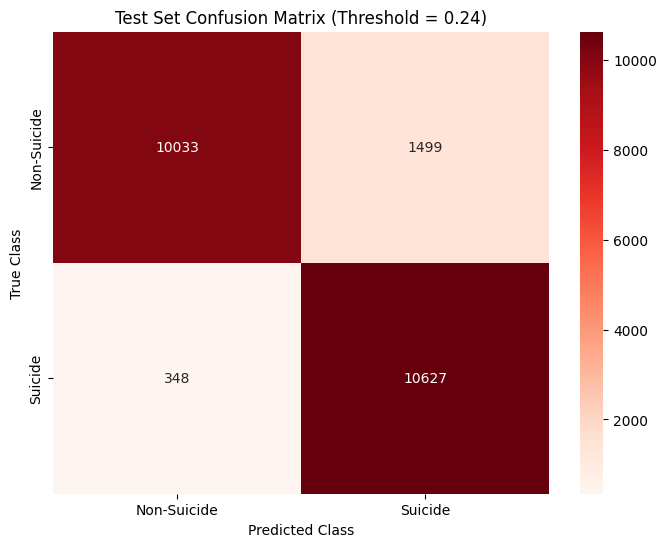

In [5]:
print(f"\nEvaluating on TEST SET with Threshold {optimal_threshold:.4f}...")
y_test_prob = clf.predict_proba(X_test)[:, 1]

y_pred_default = (y_test_prob >= 0.5).astype(int)
y_pred_optimal = (y_test_prob >= optimal_threshold).astype(int)

print("\n--- DEFAULT THRESHOLD (0.5) TEST EVAL ---")
y_test_str = np.where(y_test == 1, 'suicide', 'non-suicide')
y_pred_default_str = np.where(y_pred_default == 1, 'suicide', 'non-suicide')
print(classification_report(y_test_str, y_pred_default_str, digits=4))

print(f"\n--- OPTIMAL THRESHOLD ({optimal_threshold:.4f}) TEST EVAL ---")
y_pred_optimal_str = np.where(y_pred_optimal == 1, 'suicide', 'non-suicide')
print(classification_report(y_test_str, y_pred_optimal_str, digits=4))

cm = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Non-Suicide', 'Suicide'], yticklabels=['Non-Suicide', 'Suicide'])
plt.title(f'Test Set Confusion Matrix (Threshold = {optimal_threshold:.2f})')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.savefig('../../../docs/documentazione/latex/figures/nlp_optimal_cm.png', dpi=300, bbox_inches='tight')

plt.show()